In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms, models, datasets
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
    
    

Using device: cuda


In [4]:
dataset_path = "/kaggle/input/datasets/ninadaithal/imagesoasis/Data"

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=dataset_path)
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Total images: 86437


In [5]:
# Split sizes
total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

# Split (no transforms yet, just indices)
train_set, val_set, test_set = random_split(
    full_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply transforms by wrapping each subset
train_set.dataset.transform = train_transforms

# Build weighted sampler for class imbalance
targets = [full_dataset.targets[i] for i in train_set.indices]
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
train_loader = DataLoader(train_set, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"Train: {train_size} | Val: {val_size} | Test: {test_size}")

Train: 60505 | Val: 12965 | Test: 12967


In [15]:
def get_model(num_classes = 4):
    model = models.resnet18(pretrained=True)
     # Freeze all layers
    for param in model.parameters():
        param.requires_grad = True
    # Replace final layer — this is the only part that trains
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)
model = get_model()
print(model.fc)
print(f"Trainable params:{sum(p.numel() for p in model.parameters() if p.requires_grad)}")



Linear(in_features=512, out_features=4, bias=True)
Trainable params:11178564


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [18]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        
        # --- Training phase ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        
        # --- Validation phase ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        
        # --- Record metrics ---
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg   = val_loss / len(val_loader)
        train_acc      = train_correct / train_total * 100
        val_acc        = val_correct / val_total * 100
        
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.2f}%")
    
    return history

history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)

Epoch [1/5] Train Loss: 0.2140 | Train Acc: 91.70% | Val Loss: 0.2566 | Val Acc: 90.09%
Epoch [2/5] Train Loss: 0.0614 | Train Acc: 97.82% | Val Loss: 0.0617 | Val Acc: 97.81%
Epoch [3/5] Train Loss: 0.0374 | Train Acc: 98.67% | Val Loss: 0.0331 | Val Acc: 98.87%
Epoch [4/5] Train Loss: 0.0284 | Train Acc: 99.09% | Val Loss: 0.0712 | Val Acc: 97.48%
Epoch [5/5] Train Loss: 0.0239 | Train Acc: 99.19% | Val Loss: 0.0281 | Val Acc: 99.05%


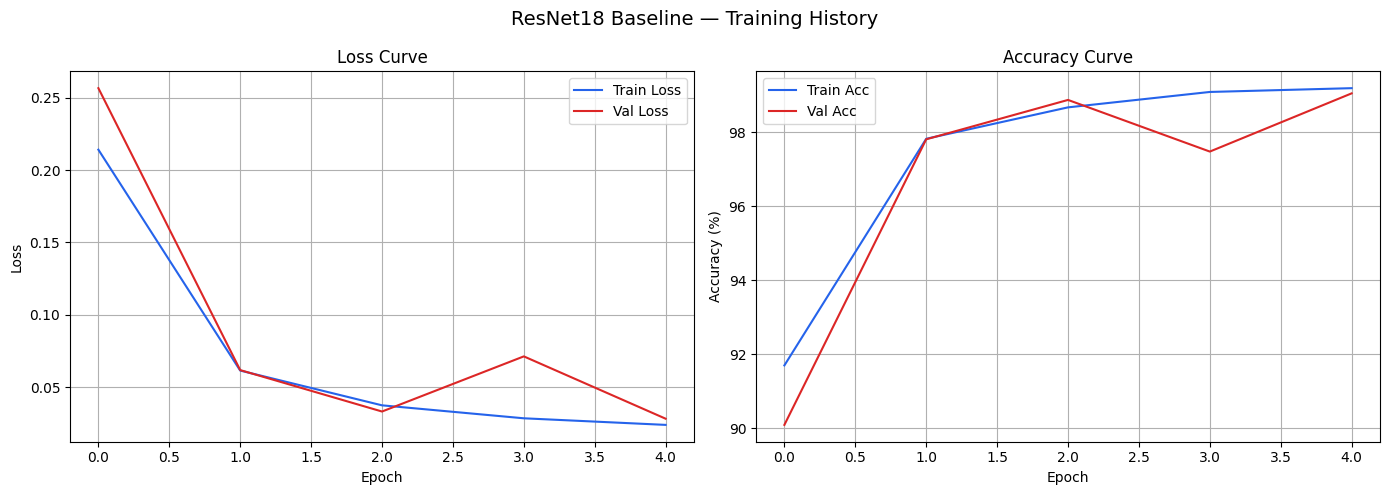

In [28]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curve
    ax1.plot(history['train_loss'], label='Train Loss', color='#2563eb')
    ax1.plot(history['val_loss'], label='Val Loss', color='#dc2626')
    ax1.set_title('Loss Curve')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy curve
    ax2.plot(history['train_acc'], label='Train Acc', color='#2563eb')
    ax2.plot(history['val_acc'], label='Val Acc', color='#dc2626')
    ax2.set_title('Accuracy Curve')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle('ResNet18 Baseline — Training History', fontsize=14)
    plt.tight_layout()
    plt.show()
plot_history(history)

In [30]:
def evaluate(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels
preds, labels = evaluate(model, test_loader)
class_names = ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very Mild Dementia']
print(classification_report(labels, preds, target_names=class_names))


                    precision    recall  f1-score   support

     Mild Dementia       0.96      0.99      0.98       742
 Moderate Dementia       0.85      1.00      0.92        82
      Non Demented       1.00      0.99      0.99     10061
Very Mild Dementia       0.97      0.98      0.98      2082

          accuracy                           0.99     12967
         macro avg       0.94      0.99      0.97     12967
      weighted avg       0.99      0.99      0.99     12967



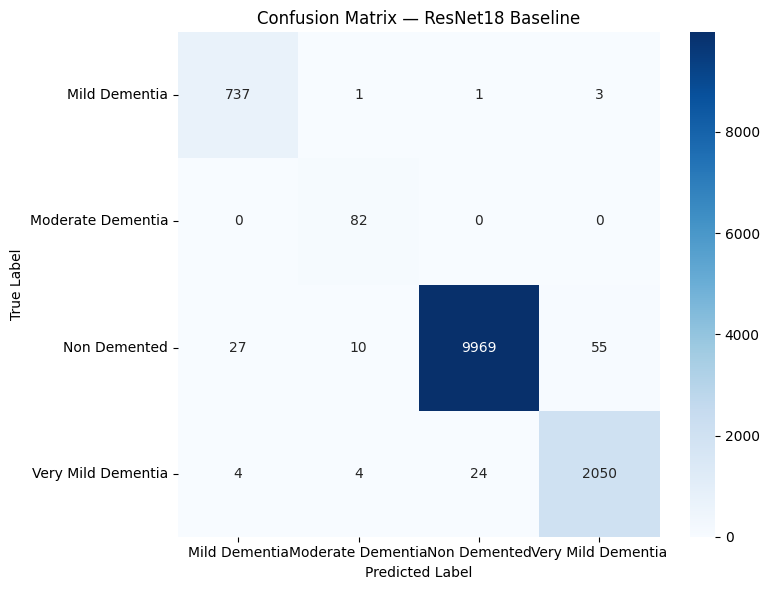

In [35]:
def plot_confusion_matrix(labels, preds, class_names):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix — ResNet18 Baseline')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(labels, preds, class_names)

In [40]:
torch.save(model.state_dict(), 'resnet18_baseline.pth')
print("Model saved.")

Model saved.
